# Fig: Distribution of last Pmax in mismatch agentLower scenario: pmax_th=0.95

Reference: 
- `20260531_fig_infotaxis_MAP_cmp_pmax0.95.ipynb`

In [1]:
from pathlib import Path

import pandas as pd

import seaborn as sns

In [2]:
from data_prep_plot.plot_utils import bar_violinplot_last_pmax
from data_prep_plot.simulation_data_prep import get_success_fname

In [3]:
# Set path
path_data = Path("/Volumes/ssd_2tb_1/infotaxis_simu_2026")

path_fig = Path("../figs_paper_2026")

Samples: left:  989    right:  926
Mean:    left: 0.987  right: 0.987
Median:  left: 0.988  right: 0.988

MWU test
 - different: 0.29859
 - less:      0.14930
 - greater:   0.85072
--------------------------------------------
Samples: left:  989    right:  832
Mean:    left: 0.987  right: 0.987
Median:  left: 0.988  right: 0.988

MWU test
 - different: 0.99222
 - less:      0.49611
 - greater:   0.50393
--------------------------------------------
Samples: left:  989    right:  618
Mean:    left: 0.987  right: 0.987
Median:  left: 0.988  right: 0.988

MWU test
 - different: 0.90860
 - less:      0.45430
 - greater:   0.54575
--------------------------------------------
Samples: left:  989    right:  245
Mean:    left: 0.987  right: 0.986
Median:  left: 0.988  right: 0.986

MWU test
 - different: 0.00008
 - less:      0.99996
 - greater:   0.00004
--------------------------------------------


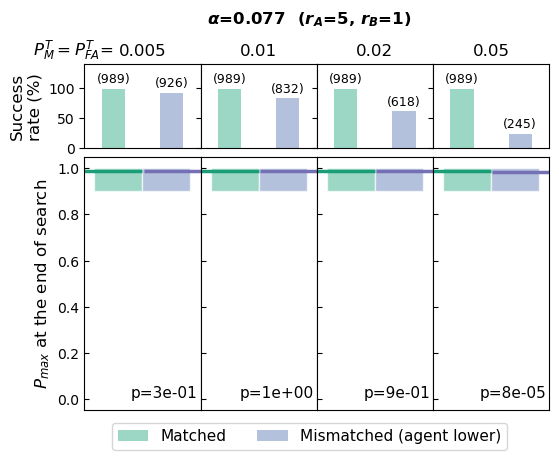

Samples: left:  977    right:  890
Mean:    left: 0.980  right: 0.980
Median:  left: 0.981  right: 0.981

MWU test
 - different: 0.76452
 - less:      0.61777
 - greater:   0.38226
--------------------------------------------
Samples: left:  977    right:  738
Mean:    left: 0.980  right: 0.979
Median:  left: 0.981  right: 0.980

MWU test
 - different: 0.08632
 - less:      0.95685
 - greater:   0.04316
--------------------------------------------
Samples: left:  977    right:  460
Mean:    left: 0.980  right: 0.979
Median:  left: 0.981  right: 0.980

MWU test
 - different: 0.07298
 - less:      0.96352
 - greater:   0.03649
--------------------------------------------
Samples: left:  977    right:  109
Mean:    left: 0.980  right: 0.979
Median:  left: 0.981  right: 0.980

MWU test
 - different: 0.35529
 - less:      0.82244
 - greater:   0.17765
--------------------------------------------


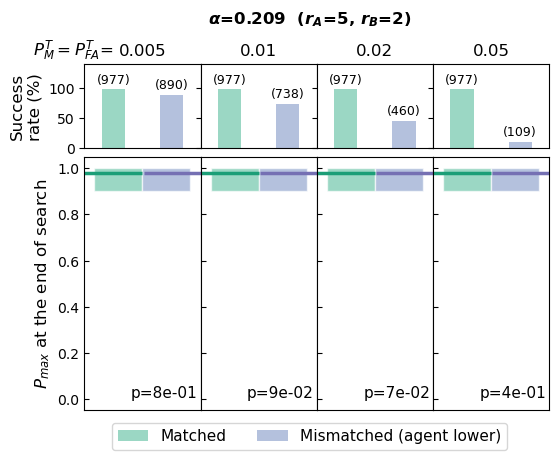

Samples: left:  986    right:  886
Mean:    left: 0.983  right: 0.983
Median:  left: 0.985  right: 0.985

MWU test
 - different: 0.68691
 - less:      0.65658
 - greater:   0.34345
--------------------------------------------
Samples: left:  986    right:  707
Mean:    left: 0.983  right: 0.984
Median:  left: 0.985  right: 0.985

MWU test
 - different: 0.91466
 - less:      0.45733
 - greater:   0.54271
--------------------------------------------
Samples: left:  986    right:  344
Mean:    left: 0.983  right: 0.981
Median:  left: 0.985  right: 0.981

MWU test
 - different: 0.00174
 - less:      0.99913
 - greater:   0.00087
--------------------------------------------
Samples: left:  986    right:   91
Mean:    left: 0.983  right: 0.982
Median:  left: 0.985  right: 0.980

MWU test
 - different: 0.03595
 - less:      0.98204
 - greater:   0.01797
--------------------------------------------


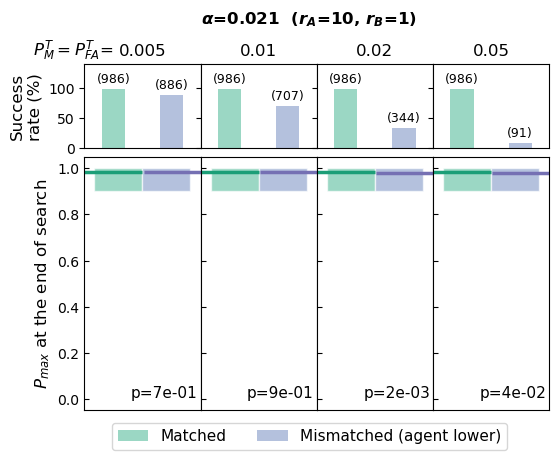

Samples: left:  980    right:  862
Mean:    left: 0.979  right: 0.979
Median:  left: 0.979  right: 0.979

MWU test
 - different: 0.66301
 - less:      0.66853
 - greater:   0.33150
--------------------------------------------
Samples: left:  980    right:  620
Mean:    left: 0.979  right: 0.979
Median:  left: 0.979  right: 0.979

MWU test
 - different: 0.79332
 - less:      0.60339
 - greater:   0.39666
--------------------------------------------
Samples: left:  980    right:  265
Mean:    left: 0.979  right: 0.980
Median:  left: 0.979  right: 0.979

MWU test
 - different: 0.41234
 - less:      0.20617
 - greater:   0.79389
--------------------------------------------
Samples: left:  980    right:   33
Mean:    left: 0.979  right: 0.979
Median:  left: 0.979  right: 0.979

MWU test
 - different: 0.72184
 - less:      0.63931
 - greater:   0.36092
--------------------------------------------


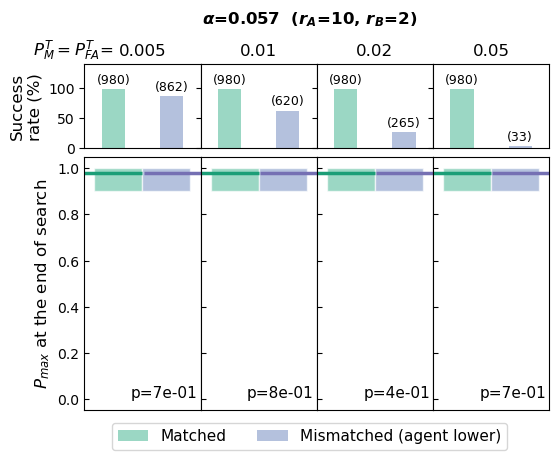

In [4]:
cr_all = [5, 10]
br_all = [1, 2]
pm_truth_all = [0.005, 0.01, 0.02, 0.05]
pm_agent_all = [0.001] * len(pm_truth_all)

for cr in cr_all:
    for br in br_all:

        path_left = path_data / "20260530_infotaxis_match_summary_compiled_pmax095_pmaxDiff1e-5"
        path_right = path_data / "20260530_infotaxis_mismatch_agentLower_summary_compiled_pmax095_pmaxDiff1e-5"
        pmax_th = 0.95
        pmax_diff_th = 1e-5

        df_x_all = []
        df_y_all = []
        for pm_agent, pm_truth in zip(pm_agent_all, pm_truth_all):
            # Load summary and ph details
            df_x = pd.read_csv(
                path_left / get_success_fname(
                    search_type="infotaxis", cr=cr, br=br, simulation_type="simple",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm_agent
                ), index_col=0
            )
            df_y = pd.read_csv(
                path_right / get_success_fname(
                    search_type="infotaxis", cr=cr, br=br, simulation_type="mismatch",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm_agent, pm_truth=pm_truth
                ), index_col=0
            )
            df_x_all.append(df_x)
            df_y_all.append(df_y)

        
        fig = bar_violinplot_last_pmax(
            cr=cr, br=br, pm_all=pm_truth_all,
            df_x_all=df_x_all, df_y_all=df_y_all,
            x_str="Matched", y_str="Mismatched (agent lower)",
            comparison_type="agent_lower",
            stats_type="two-sided",
            colors=sns.color_palette("Set2"),
            colors_dark=sns.color_palette("Dark2"),
            bar_step=0.1,
            color_idx_left=0, color_idx_right=2,
            alpha=0.65
        )

        fig.savefig(
            path_fig / f"fig_last_pmax_mismatch_agentLower_cr{cr}_br{br}_pmaxTh0.95_pmaxDiff1e-5.png",
            dpi=300, bbox_inches="tight"
        )